<a href="https://colab.research.google.com/github/shejal1123/Linear-Regression/blob/main/in_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('/content/Salary_Dataset_DataScienceLovers.csv')
df

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android
...,...,...,...,...,...,...,...,...
22765,4.7,Expert Solutions,Web Developer,200000,1,Bangalore,Full Time,Web
22766,4.0,Nextgen Innovation Labs,Web Developer,300000,1,Bangalore,Full Time,Web
22767,4.1,Fresher,Full Stack Web Developer,192000,13,Bangalore,Full Time,Web
22768,4.1,Accenture,Full Stack Web Developer,300000,7,Bangalore,Full Time,Web


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22770 entries, 0 to 22769
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rating             22770 non-null  float64
 1   Company Name       22769 non-null  object 
 2   Job Title          22770 non-null  object 
 3   Salary             22770 non-null  int64  
 4   Salaries Reported  22770 non-null  int64  
 5   Location           22770 non-null  object 
 6   Employment Status  22770 non-null  object 
 7   Job Roles          22770 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 1.4+ MB


In [6]:
df.isnull().sum()

,0
Rating,0
Company Name,1
Job Title,0
Salary,0
Salaries Reported,0
Location,0
Employment Status,0
Job Roles,0


In [7]:
print("Mean of numerical columns:")
display(df.select_dtypes(include=['number']).mean())

Mean of numerical columns:


,0
Rating,3.918213
Salary,695387.211243
Salaries Reported,1.855775


In [8]:
print("Mode of all columns:")
display(df.mode().head())

Mode of all columns:


,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,4.0,Tata Consultancy Services,Software Development Engineer,300000,1,Bangalore,Full Time,SDE


In [9]:
# Fill null values in 'Company Name' with its mode
company_name_mode = df['Company Name'].mode()[0]
df['Company Name'].fillna(company_name_mode, inplace=True)

# Verify that there are no more null values
print("Null values after filling:")
display(df.isnull().sum())

Null values after filling:


/tmp/ipykernel_1807/963275802.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Company Name'].fillna(company_name_mode, inplace=True)


,0
Rating,0
Company Name,0
Job Title,0
Salary,0
Salaries Reported,0
Location,0
Employment Status,0
Job Roles,0


In [10]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Apply Label Encoding
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("DataFrame after Label Encoding:")
display(df.head())

print("Number of unique values in each encoded categorical column:")
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")

DataFrame after Label Encoding:


,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,8129,28,400000,3,0,1,0
1,4.5,417,28,400000,3,0,1,0
2,4.0,9777,28,1000000,3,0,1,0
3,3.8,8533,28,300000,3,0,1,0
4,4.4,884,28,600000,3,0,1,0


Number of unique values in each encoded categorical column:
Company Name: 11260 unique values
Job Title: 1080 unique values
Location: 10 unique values
Employment Status: 4 unique values
Job Roles: 11 unique values


In [12]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('Salary', axis=1)
y = df['Salary']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (18216, 7)
Shape of X_test: (4554, 7)
Shape of y_train: (18216,)
Shape of y_test: (4554,)


### Model 1: Linear Regression

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize and train the Linear Regression model
linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train)

# Make predictions
y_pred_lr = linear_reg.predict(X_test)

# Evaluate the model
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = mse_lr**0.5
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Model Performance:")
print(f"Mean Absolute Error: {mae_lr:.2f}")
print(f"Mean Squared Error: {mse_lr:.2f}")
print(f"Root Mean Squared Error: {rmse_lr:.2f}")
print(f"R-squared: {r2_lr:.2f}")

Linear Regression Model Performance:
Mean Absolute Error: 414592.23
Mean Squared Error: 386545874783.28
Root Mean Squared Error: 621728.14
R-squared: 0.05


### Model 2: Decision Tree Regressor

In [14]:
from sklearn.tree import DecisionTreeRegressor

# Initialize and train the Decision Tree Regressor model
decision_tree_reg = DecisionTreeRegressor(random_state=42)
decision_tree_reg.fit(X_train, y_train)

# Make predictions
y_pred_dt = decision_tree_reg.predict(X_test)

# Evaluate the model
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = mse_dt**0.5
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Regressor Model Performance:")
print(f"Mean Absolute Error: {mae_dt:.2f}")
print(f"Mean Squared Error: {mse_dt:.2f}")
print(f"Root Mean Squared Error: {rmse_dt:.2f}")
print(f"R-squared: {r2_dt:.2f}")

Decision Tree Regressor Model Performance:
Mean Absolute Error: 526871.46
Mean Squared Error: 2484415021401.04
Root Mean Squared Error: 1576202.72
R-squared: -5.13


### Model 3: Random Forest Regressor

In [15]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest Regressor model
random_forest_reg = RandomForestRegressor(random_state=42)
random_forest_reg.fit(X_train, y_train)

# Make predictions
y_pred_rf = random_forest_reg.predict(X_test)

# Evaluate the model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = mse_rf**0.5
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor Model Performance:")
print(f"Mean Absolute Error: {mae_rf:.2f}")
print(f"Mean Squared Error: {mse_rf:.2f}")
print(f"Root Mean Squared Error: {rmse_rf:.2f}")
print(f"R-squared: {r2_rf:.2f}")

Random Forest Regressor Model Performance:
Mean Absolute Error: 399743.10
Mean Squared Error: 623993827858.30
Root Mean Squared Error: 789932.80
R-squared: -0.54


### Regression Model Metrics Summary

In [16]:
print("Linear Regression Model Performance:")
print(f"  Mean Absolute Error: {mae_lr:.2f}")
print(f"  Mean Squared Error: {mse_lr:.2f}")
print(f"  Root Mean Squared Error: {rmse_lr:.2f}")
print(f"  R-squared: {r2_lr:.2f}")

print("\nDecision Tree Regressor Model Performance:")
print(f"  Mean Absolute Error: {mae_dt:.2f}")
print(f"  Mean Squared Error: {mse_dt:.2f}")
print(f"  Root Mean Squared Error: {rmse_dt:.2f}")
print(f"  R-squared: {r2_dt:.2f}")

print("\nRandom Forest Regressor Model Performance:")
print(f"  Mean Absolute Error: {mae_rf:.2f}")
print(f"  Mean Squared Error: {mse_rf:.2f}")
print(f"  Root Mean Squared Error: {rmse_rf:.2f}")
print(f"  R-squared: {r2_rf:.2f}")

Linear Regression Model Performance:
  Mean Absolute Error: 414592.23
  Mean Squared Error: 386545874783.28
  Root Mean Squared Error: 621728.14
  R-squared: 0.05

Decision Tree Regressor Model Performance:
  Mean Absolute Error: 526871.46
  Mean Squared Error: 2484415021401.04
  Root Mean Squared Error: 1576202.72
  R-squared: -5.13

Random Forest Regressor Model Performance:
  Mean Absolute Error: 399743.10
  Mean Squared Error: 623993827858.30
  Root Mean Squared Error: 789932.80
  R-squared: -0.54


### Visual Comparison of Model Performance Metrics

### Saving Models using Pickle Format

We will use Python's `pickle` module to save the trained models. This allows us to persist the models to disk and load them back later without needing to retrain them.

In [19]:
import pickle

# Save Linear Regression Model
with open('linear_regression_model.pkl', 'wb') as f:
    pickle.dump(linear_reg, f)
print("Linear Regression model saved as linear_regression_model.pkl")

# Save Decision Tree Regressor Model
with open('decision_tree_model.pkl', 'wb') as f:
    pickle.dump(decision_tree_reg, f)
print("Decision Tree Regressor model saved as decision_tree_model.pkl")

# Save Random Forest Regressor Model
with open('random_forest_model.pkl', 'wb') as f:
    pickle.dump(random_forest_reg, f)
print("Random Forest Regressor model saved as random_forest_model.pkl")

Linear Regression model saved as linear_regression_model.pkl
Decision Tree Regressor model saved as decision_tree_model.pkl
Random Forest Regressor model saved as random_forest_model.pkl


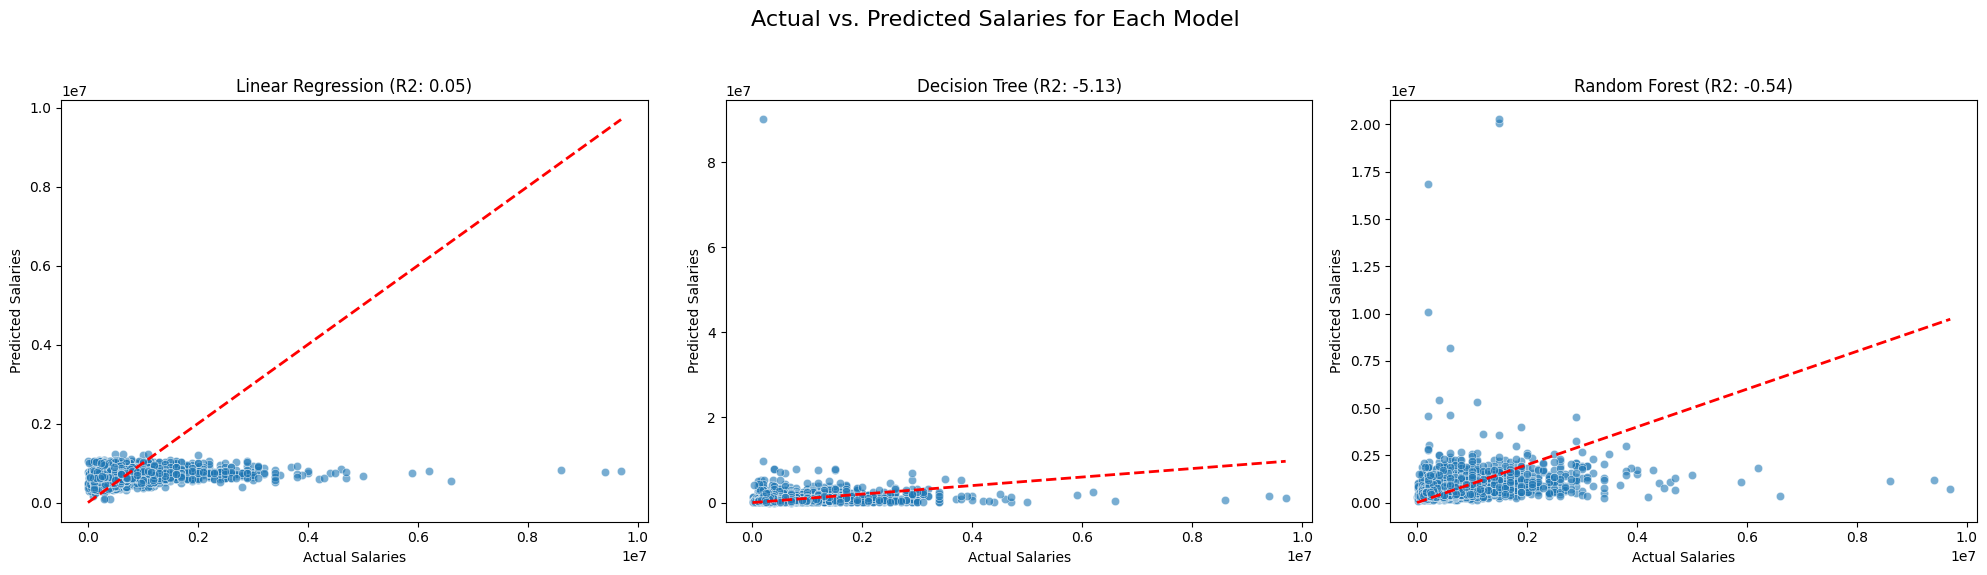

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Actual vs. Predicted Salaries for Each Model', fontsize=16)

# Plot for Linear Regression
sns.scatterplot(x=y_test, y=y_pred_lr, ax=axes[0], alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title(f'Linear Regression (R2: {r2_lr:.2f})')
axes[0].set_xlabel('Actual Salaries')
axes[0].set_ylabel('Predicted Salaries')

# Plot for Decision Tree Regressor
sns.scatterplot(x=y_test, y=y_pred_dt, ax=axes[1], alpha=0.6)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_title(f'Decision Tree (R2: {r2_dt:.2f})')
axes[1].set_xlabel('Actual Salaries')
axes[1].set_ylabel('Predicted Salaries')

# Plot for Random Forest Regressor
sns.scatterplot(x=y_test, y=y_pred_rf, ax=axes[2], alpha=0.6)
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[2].set_title(f'Random Forest (R2: {r2_rf:.2f})')
axes[2].set_xlabel('Actual Salaries')
axes[2].set_ylabel('Predicted Salaries')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [11]:
df.duplicated().sum()

np.int64(0)

In [20]:
import pickle

# Load the Linear Regression model
with open('linear_regression_model.pkl', 'rb') as f:
    loaded_linear_reg_model = pickle.load(f)

print("Linear Regression model loaded successfully!")

# You can now use the loaded model for predictions
# For example, to make a prediction using the first row of X_test:
# sample_prediction = loaded_linear_reg_model.predict(X_test.head(1))
# print(f"Prediction using loaded model: {sample_prediction[0]:.2f}")

Linear Regression model loaded successfully!
